In [343]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics

import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from catboost import CatBoostClassifier

import statistics
from scipy import stats

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, \
AdaBoostClassifier, VotingClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import SGDClassifier, RidgeClassifier, ElasticNet, LogisticRegression
from sklearn.feature_selection import SelectFromModel

from sklearn.model_selection import train_test_split, cross_val_score \
,GridSearchCV, KFold, RepeatedKFold, StratifiedKFold, ShuffleSplit, StratifiedShuffleSplit \
, RandomizedSearchCV


%matplotlib inline

# Define the problem and analyze it from a broader perspective

## 1. Define the objective in business terms

The goal of the project is to develop predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data.

## 2. Describe how your solution will be used
My solution will be used as a predictive model that can be implemented in several forms, such as:

* a web application
* an API
* an analytical dashboard
* a reporting module
* integration with mobile applications

## 3. Identify existing solutions or workarounds (if any)
#### Traditional valuation methods:

* Rule-based heuristics (e.g. gender, age, passenger class)
* Classical statistical scoring
* Descriptive statistical analysis

---

#### Existing technological solutions:

* Offline predictive modeling with probabilistic output
* Alternative data scoring

## 4. In which categories should the problem be defined (unsupervised/supervised, incremental/static, etc.)?

* **Learning:** supervised
* **Prediction type:** classification (binary: survived / not survived), optionally regression (probability of survival)
* **Learning mode:** static (historical dataset, offline training)
* **Type of data:** tabular (passenger attributes)

## 5. How will the model's performance be measured?
The results are evaluated using the percentage of passengers you correctly predict. This is known as accuracy.

## 6. Is the performance measurement linked to the business objective?

The objective of the project is to correctly predict whether a passenger survived the Titanic disaster based on available attributes.
Model performance is evaluated using accuracy, defined as the percentage of passengers whose survival outcome is correctly predicted.
Accuracy directly reflects how well the model achieves the project goal of maximizing correct survival predictions on the historical dataset.

## 7. What is the minimum performance required to meet the business objective?

The minimum required performance is an accuracy of at least 70%, which ensures that the model performs better than simple baseline strategies and provides meaningful predictive value for survival classification.

## 8. Are there any comparable problems? Can you leverage existing experience or tools?

The problem is comparable to standard binary classification tasks such as customer churn prediction, medical survival analysis, or fraud detection, where the goal is to predict a binary outcome based on tabular features.

#### Tools:
* **Machine learning:** well-established classification models and data preprocessing techniques

## 9. Can you get help from experts?
No

## 10. How can the problem be solved manually?

The problem can be solved manually using simple heuristics based on historical knowledge, such as prioritizing women, children, and higher-class passengers, but this approach is subjective, not scalable, and less accurate than data-driven classification models.

## 11. Make a list of assumptions established by you (or others)
#### Assumptions regarding the data:

* **Availability of historical data:** It is assumed that sufficient historical passenger data from the Titanic disaster is available for training and evaluation.
* **High data quality:** It is assumed that the dataset is generally reliable; missing values (e.g. age, cabin) can be handled using standard imputation techniques.
* **Consistency of features:** All variables are assumed to be consistently defined and measured (e.g. passenger class, fare, age).
---

#### **Assumptions regarding the model:**

* **Classification model:** It is assumed that the task is a binary classification problem (survived / not survived).
* **Baseline model first:** Initially, simple and interpretable models (e.g. logistic regression, decision trees) are used as a baseline.
* **Possibility of advanced models:** If baseline performance is insufficient, more advanced models (e.g. Random Forest, Gradient Boosting) may be applied.
* **Model generalization:** The model is expected to generalize well to unseen passenger records from the same data distribution.

---

#### **Assumptions regarding model performance:**

* **Expected accuracy level:** It is assumed that the model will achieve an accuracy exceeding a simple baseline (e.g. majority class prediction).
* **Offline evaluation::** Model performance is evaluated offline on a validation or test set.
* **Stability across subsets:** The model is expected to maintain comparable performance across passenger subgroups (e.g. gender, class).
* **Reproducibility:** The training and evaluation process is assumed to be reproducible using fixed data splits and random seeds.

# Data acquisition

## 1. Specify the type and amount of data needed
The provided data is in CSV format , separated to test and train set. Train set contains 891 rows and 12 columns and the Test set contains 418 rows and  11 columns.

## 2. Identify the source from which you can obtain the data and document it
https://www.kaggle.com/competitions/titanic/data

## 3. Check how much storage space will be needed to store the data
The data requires less than 2 MB of disk space.

## 4. Acquire the data and convert it into a format that allows easy manipulation (without changing the essence of the data), and ensure that sensitive data has been removed or secured (e.g., masked).

In [344]:
df_train = pd.read_csv('../data/raw/train.csv')
df_test = pd.read_csv('../data/raw/test.csv')

In [345]:
#no need to mask sensitive data
df_train.iloc[0].values

array([1, 0, 3, 'Braund, Mr. Owen Harris', 'male', 22.0, 1, 0,
       'A/5 21171', 7.25, nan, 'S'], dtype=object)

## 5. Check the size and type of the data

In [346]:
df_train.shape,df_test.shape

((891, 12), (418, 11))

In [347]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [348]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


## 6. Split the test set(if needed)

In [349]:
df_test = pd.read_csv('../data/raw/test.csv')
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


# Data analysis

## 1. Create a copy of the data being analyzed (resampling it to a reasonable size if necessary)

In [350]:
df_train_copy = df_train.copy()
df_test_copy = df_test.copy()

## 2. For supervised learning tasks, identify the target attribute

In [351]:
df_train[['Survived']].head()

,Survived
0,0
1,1
2,1
3,1
4,0


In [352]:
df_train_copy['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [353]:
#df_train_copy['Survived'] = df_train_copy['Survived'].astype('category')

## 3. Identify each attribute and its parameters

In [354]:
df_train_copy.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

* **PassengerId:** A unique identifier for each passenger.

* **Survived:** The target variable indicating whether the passenger survived the disaster (0 = No, 1 = Yes).

* **Pclass:** The passenger’s ticket class, representing socio-economic status (1 = First class, 2 = Second class, 3 = Third class).

* **Name:** The full name of the passenger as listed on the ticket.

* **Sex:** The biological sex of the passenger (male, female).

* **Age:** The age of the passenger in years.

* **SibSp:** The number of siblings or spouses aboard the Titanic.

* **Parch:** The number of parents or children aboard the Titanic.

* **Ticket:** The ticket number assigned to the passenger.

* **Fare:** The fare paid for the ticket.

* **Cabin:** The cabin number assigned to the passenger (if available).

* **Embarked:** The port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton).


---------------------

**Variable Notes**
pclass: A proxy for socio-economic status (SES)
1st = Upper
2nd = Middle
3rd = Lower

age: Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5

sibsp: The dataset defines family relations in this way...
Sibling = brother, sister, stepbrother, stepsister
Spouse = husband, wife (mistresses and fiancés were ignored)

parch: The dataset defines family relations in this way...
Parent = mother, father
Child = daughter, son, stepdaughter, stepson
Some children travelled only with a nanny, therefore parch=0 for them.

In [355]:
#divide dataset to get numerical and categorical data
def num_cat_divider(df):
    numerical = df.select_dtypes(include='number').drop('PassengerId', axis=1)
    categorical = df.select_dtypes(exclude='number')
    return numerical, categorical

numerical, categorical = num_cat_divider(df_train_copy)

In [356]:
#make outliers detector
def outliers_detection(df, columns):
    outliers = []
    for column in columns:
        std= df[column].std()
        mean= df[column].mean()
        outlier_data= df[(df[column] > mean + 2 * std) |
                         (df[column] < mean - 2 * std)]
        outliers.append(outlier_data[column].count())
    return outliers

In [357]:
#describe numerical and categorical data
class DataDescriber:
    def __init__(self,df,specs):
        self.df = df
        self.specs = specs
        self.data = None
        if 'PassengerId' in df.columns:
            self.num_features = self.df.select_dtypes(include=['number']).drop('PassengerId', axis=1)
        else:
            self.num_features = self.df.select_dtypes(include=['number'])
        self.cat_features = self.df.select_dtypes(exclude='number')
        
        if self.specs == 'numerical':
            self.numerical_describer()
        elif self.specs == 'categorical':
            self.categorical_describer()
        elif self.specs == 'full':
            self.full_describer()


    def numerical_describer(self):
        num_data_desc = pd.DataFrame(index=list(self.num_features))
        num_data_desc['type'] = self.num_features.dtypes
        num_data_desc['count'] = self.num_features.count()
        num_data_desc['nunique'] = self.num_features.nunique()
        num_data_desc['%unique'] = num_data_desc['nunique'] / len(self.num_features) * 100
        num_data_desc['null'] = self.num_features.isnull().sum()
        num_data_desc['%null'] = num_data_desc['null'] / len(self.num_features) * 100
        num_data_desc['min'] = self.num_features.min()
        num_data_desc['max'] = self.num_features.max()
        num_data_desc['mean'] = self.num_features.mean()
        num_data_desc['median'] = self.num_features.median()
        num_data_desc['std'] = self.num_features.std()
        num_data_desc['outliers'] = outliers_detection(self.df,list(self.num_features))
        num_data_desc['%outliers'] = num_data_desc['outliers'] / len(self.num_features) * 100
        self.data = num_data_desc
        return num_data_desc
        
    def categorical_describer(self):
        cat_data_desc = pd.DataFrame(index = list(self.cat_features))
        cat_data_desc['type'] = self.cat_features.dtypes
        cat_data_desc['count'] = self.cat_features.count()
        cat_data_desc['nunique'] = self.cat_features.nunique()
        cat_data_desc['%unique'] = cat_data_desc['nunique'] / len(self.cat_features) * 100
        cat_data_desc['null'] = self.cat_features.isnull().sum()
        cat_data_desc['%null'] = cat_data_desc['null'] / len(self.cat_features) * 100
        self.data = cat_data_desc
        return cat_data_desc
        
    def full_describer(self):
        cols_to_concat = ['type','count','nunique','%unique','null','%null']
        num_df = self.numerical_describer()
        cat_df = self.categorical_describer()
        num_cat_data_described = pd.concat((num_df[cols_to_concat],cat_df[cols_to_concat]), axis=0)
        self.data = num_cat_data_described

    def show_data(self):
        return self.data

In [358]:
#show described numerical data
num_data_described = DataDescriber(df_train_copy, 'numerical').show_data()
num_data_described

,type,count,nunique,%unique,null,%null,min,max,mean,median,std,outliers,%outliers
Survived,int64,891,2,0.224467,0,0.00000,0.00,1.0000,0.383838,0.0000,0.486592,0,0.000000
Pclass,int64,891,3,0.336700,0,0.00000,1.00,3.0000,2.308642,3.0000,0.836071,0,0.000000
Age,float64,714,88,9.876543,177,19.86532,0.42,80.0000,29.699118,28.0000,14.526497,29,3.254770
SibSp,int64,891,7,0.785634,0,0.00000,0.00,8.0000,0.523008,0.0000,1.102743,46,5.162738
Parch,int64,891,7,0.785634,0,0.00000,0.00,6.0000,0.381594,0.0000,0.806057,95,10.662177
Fare,float64,891,248,27.833895,0,0.00000,0.00,512.3292,32.204208,14.4542,49.693429,38,4.264871


In [359]:
# show described categorical data
cat_data_described = DataDescriber(df_train_copy, 'categorical').show_data()
cat_data_described 

,type,count,nunique,%unique,null,%null
Name,object,891,891,100.000000,0,0.000000
Sex,object,891,2,0.224467,0,0.000000
Ticket,object,891,681,76.430976,0,0.000000
Cabin,object,204,147,16.498316,687,77.104377
Embarked,object,889,3,0.336700,2,0.224467


In [360]:
#show described both numerical and categorical data
num_cat_data_described = DataDescriber(df_train_copy,'full').show_data()
num_cat_data_described

,type,count,nunique,%unique,null,%null
Survived,int64,891,2,0.224467,0,0.000000
Pclass,int64,891,3,0.336700,0,0.000000
Age,float64,714,88,9.876543,177,19.865320
SibSp,int64,891,7,0.785634,0,0.000000
Parch,int64,891,7,0.785634,0,0.000000
Fare,float64,891,248,27.833895,0,0.000000
Name,object,891,891,100.000000,0,0.000000
Sex,object,891,2,0.224467,0,0.000000
Ticket,object,891,681,76.430976,0,0.000000
Cabin,object,204,147,16.498316,687,77.104377


## 4. Visualize the data

Text(0.5, 1.0, 'Distribution of Survival,(1 = Survived)')

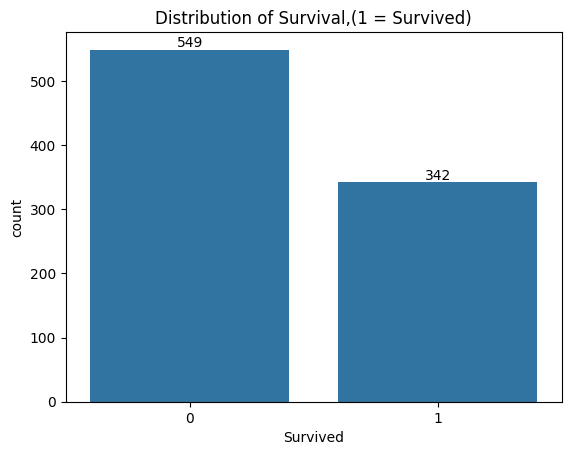

In [361]:
#plot distribution of survival
ax = sns.barplot(df_train_copy, x='Survived', y=df_train_copy['Survived'].value_counts())
ax.bar_label(ax.containers[0], fontsize=10)
ax.set_title('Distribution of Survival,(1 = Survived)')

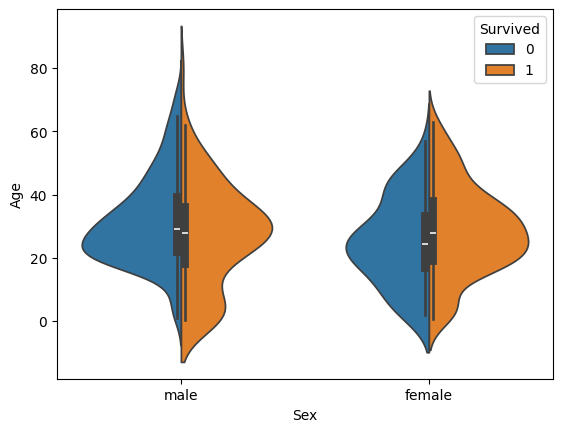

In [362]:
#plot distribution of survival by age and sex
ax2 = sns.violinplot(data=df_train_copy, x='Sex', y='Age', hue='Survived',
                    split=True)

Text(0.5, 1.0, 'Distribution of Survival,(1 = Survived) by Age and Sex')

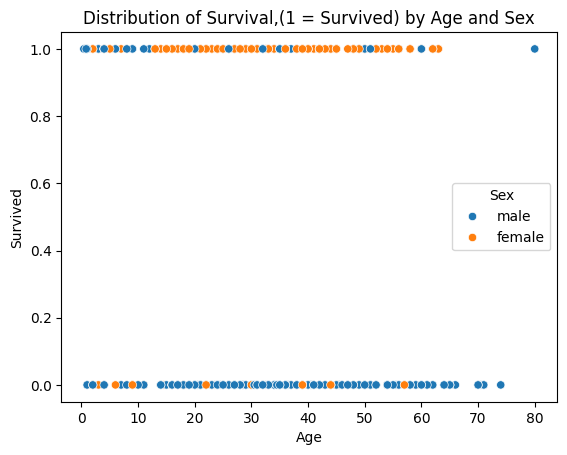

In [363]:
#plot distribution of survival by age and sex
ax3 = sns.scatterplot(df_train_copy, y='Survived',x='Age', hue='Sex')
ax3.set_title('Distribution of Survival,(1 = Survived) by Age and Sex')

Text(0.5, 1.0, 'Class Distribution')

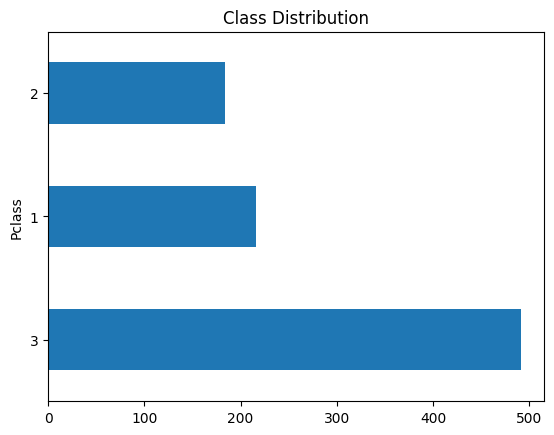

In [364]:
#plot distribution of passengers over pclass
ax4=df_train_copy['Pclass'].value_counts().plot(kind="barh")
plt.title("Class Distribution")

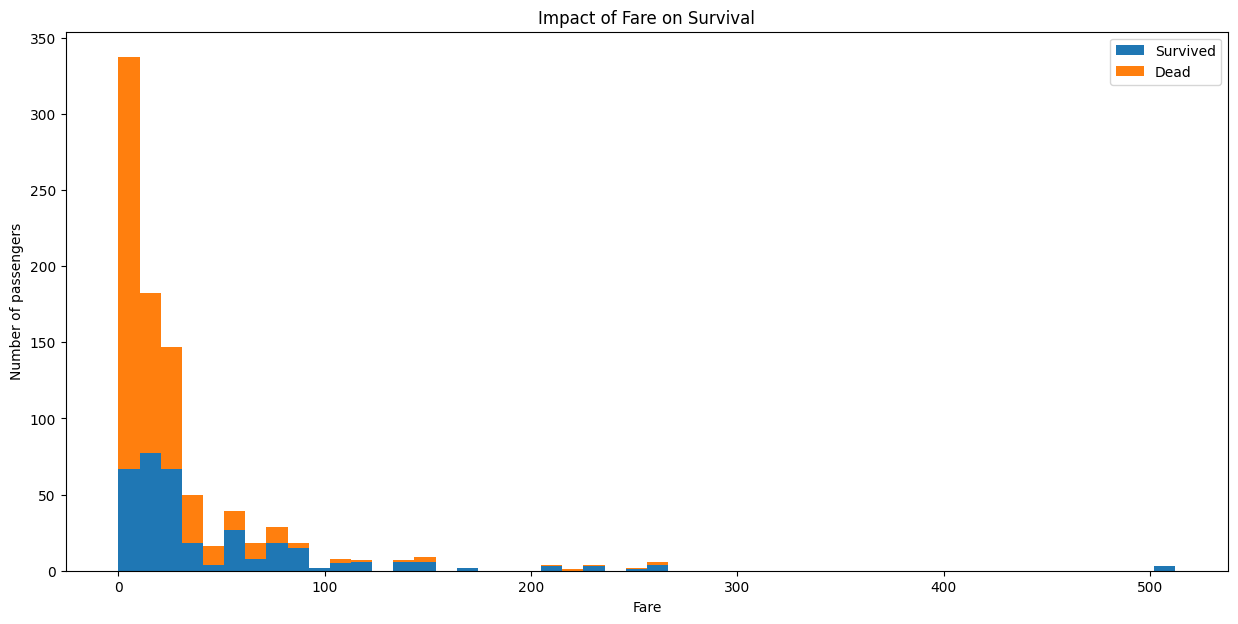

In [365]:
#Impact of Fare on Survival
ax5 = plt.figure(figsize=(15,7))
plt.hist([df_train_copy[df_train_copy['Survived'] == 1 ]['Fare'],
          df_train_copy[df_train_copy['Survived'] == 0 ]['Fare']],
          stacked = True,
          bins = 50,
          label = ['Survived', 'Dead'])
plt.xlabel('Fare')
plt.ylabel('Number of passengers')
plt.title('Impact of Fare on Survival')
plt.legend()

<Axes: xlabel='Pclass', ylabel='Average fare'>

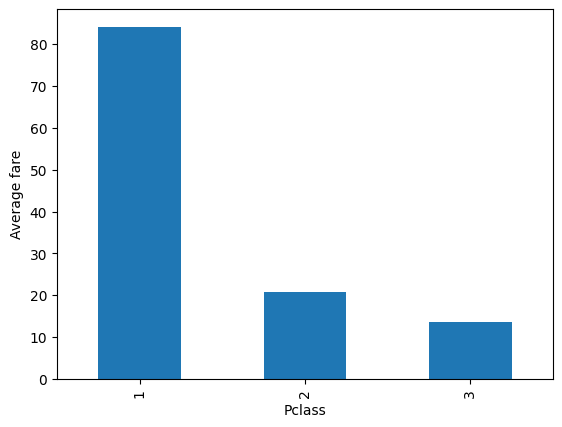

In [366]:
#ticket fare correlation with the passenger class
ax6 = plt.subplot()
ax6.set_ylabel('Average fare')
df_train_copy.groupby('Pclass')['Fare'].mean().plot(kind='bar', ax=ax6)

<Axes: xlabel='Embarked', ylabel='Fare'>

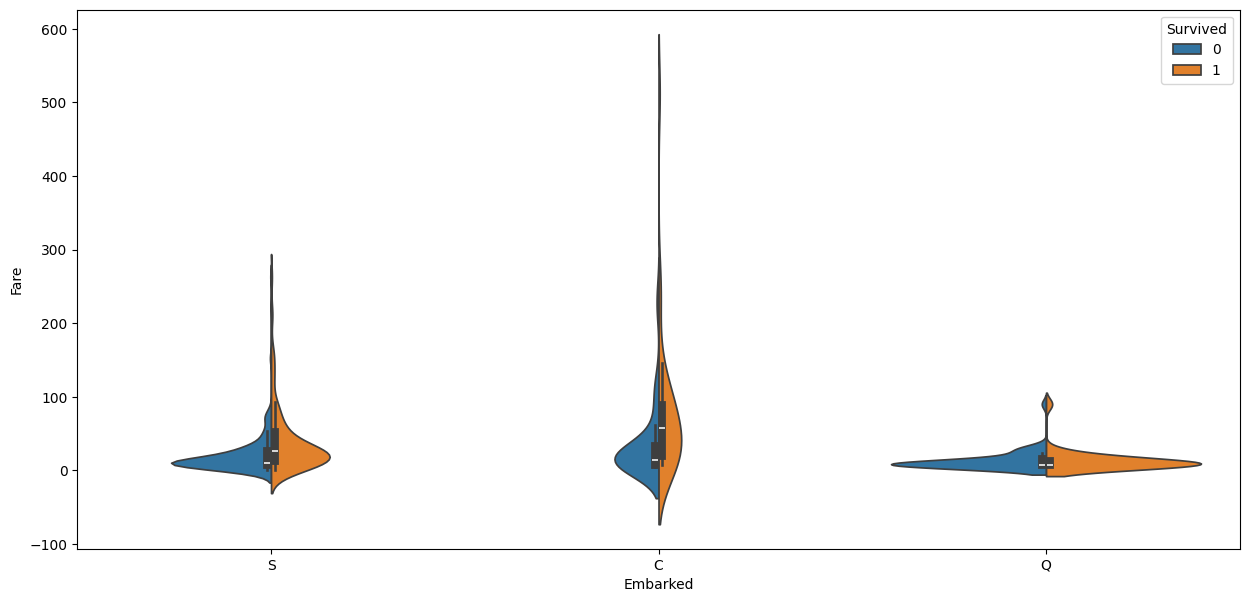

In [367]:
#embarkation effect on survival
fig = plt.figure(figsize=(15,7))
sns.violinplot(data=df_train_copy, x='Embarked', y='Fare', hue='Survived', split=True)

## 5. Analyze the correlations between attributes.

<Axes: >

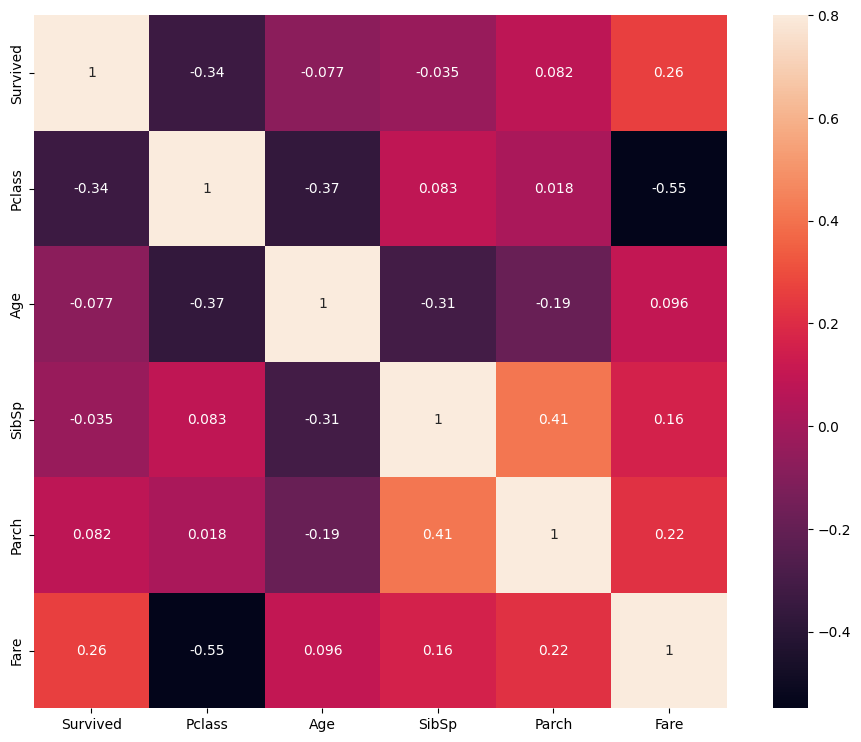

In [368]:
num_corr = numerical.corr()
f, ax = plt.subplots(figsize=(12,9))
sns.heatmap(num_corr, vmax=.8, square=True, annot=True)

In [369]:
#correlation with each other
corr_pairs = num_corr.abs().stack().reset_index()
corr_pairs.columns=['Feature 1','Feature 2','Correlation']
corr_pairs = corr_pairs[corr_pairs['Feature 1'] < corr_pairs['Feature 2']]
top_corr_pairs = corr_pairs.sort_values(by='Correlation', ascending=False)
top_corr_pairs.head(10)

,Feature 1,Feature 2,Correlation
31,Fare,Pclass,0.549500
27,Parch,SibSp,0.414838
13,Age,Pclass,0.369226
6,Pclass,Survived,0.338481
15,Age,SibSp,0.308247
30,Fare,Survived,0.257307
34,Fare,Parch,0.216225
16,Age,Parch,0.189119
33,Fare,SibSp,0.159651
17,Age,Fare,0.096067


In [370]:
#correlation with target feature
df_train_copy[numerical.columns.to_list()].corrwith(df_train_copy['Survived'])

Survived    1.000000
Pclass     -0.338481
Age        -0.077221
SibSp      -0.035322
Parch       0.081629
Fare        0.257307
dtype: float64

In [371]:
#correlation with target feature t-test
for col in numerical.columns.to_list():
    group0 = df_train_copy[df_train_copy['Survived'] == 0][col]
    group1 = df_train_copy[df_train_copy['Survived'] == 1][col]
    
    t_stat, p_value = stats.ttest_ind(group0, group1)
    print(f'{col}: t-stat = {t_stat:.3f}, p-value = {p_value:.3f}')

Survived: t-stat = -inf, p-value = 0.000
Pclass: t-stat = 10.725, p-value = 0.000
Age: t-stat = nan, p-value = nan
SibSp: t-stat = 1.054, p-value = 0.292
Parch: t-stat = -2.442, p-value = 0.015
Fare: t-stat = -7.939, p-value = 0.000


## 6. Summary

* Few columns contain missing data. Features with a small number of missing values will be imputed.

# Data preparation

In [372]:
df_train_to_clean = df_train_copy.copy(deep=True)
df_train_to_clean.shape

(891, 12)

## 1. Data cleaning

In [373]:
# scrap some information from both sets and make changes, for this
# we need full both sets combined

def combine_data():
    my_train = df_train.copy()
    my_test = df_test.copy()
    
    targets = my_train['Survived']
    my_train = my_train.drop(['Survived'], axis=1)
    
    combined = pd.concat([my_train, my_test], axis=0)
    combined.reset_index(inplace=True, drop=True)
    combined.drop(['PassengerId'],axis=1, inplace=True)
    
    return combined

combined = combine_data()

In [374]:
combined.shape

(1309, 10)

### Filling missing values

In [375]:
#show missing values
def describe_missing_data(df):
    columns_with_missing_values = df.columns[df.isnull().any()]
    df_columns_with_missing_values = df[columns_with_missing_values]
    desc_missing_data = pd.DataFrame(index = list(df_columns_with_missing_values))
    desc_missing_data['type'] = df_columns_with_missing_values.dtypes
    desc_missing_data['count'] = df_columns_with_missing_values.count()
    desc_missing_data['nunique'] = df_columns_with_missing_values.nunique()
    desc_missing_data['%unique'] = desc_missing_data['nunique'] / len(df_columns_with_missing_values) * 100
    desc_missing_data['null'] = df_columns_with_missing_values.isnull().sum()
    desc_missing_data['%null'] = desc_missing_data['null'] / len(df_columns_with_missing_values) * 100
    return desc_missing_data

described_missing_data = describe_missing_data(combined)
described_missing_data

,type,count,nunique,%unique,null,%null
Age,float64,1046,98,7.486631,263,20.091673
Fare,float64,1308,281,21.466769,1,0.076394
Cabin,object,295,186,14.209320,1014,77.463713
Embarked,object,1307,3,0.229183,2,0.152788


In [376]:
described_missing_train_data = describe_missing_data(df_train)
described_missing_train_data

,type,count,nunique,%unique,null,%null
Age,float64,714,88,9.876543,177,19.865320
Cabin,object,204,147,16.498316,687,77.104377
Embarked,object,889,3,0.336700,2,0.224467


In [377]:
described_missing_test_data = describe_missing_data(df_test)
described_missing_test_data

,type,count,nunique,%unique,null,%null
Age,float64,332,79,18.899522,86,20.574163
Fare,float64,417,169,40.430622,1,0.239234
Cabin,object,91,76,18.181818,327,78.229665


***Creating Title***

In [378]:
#extract and create titles
def title_extracter(df):
    df['Surname'] = df['Name'].str.split(',', expand=True)[0]
    df['Title']=df['Name'].str.split('.').str[0].str.split(',').str[1].str.strip()
    return df 

In [379]:
set(title_extracter(combined)['Title'])

{'Capt',
 'Col',
 'Don',
 'Dona',
 'Dr',
 'Jonkheer',
 'Lady',
 'Major',
 'Master',
 'Miss',
 'Mlle',
 'Mme',
 'Mr',
 'Mrs',
 'Ms',
 'Rev',
 'Sir',
 'the Countess'}

In [380]:
title_dict = {'Capt':'Officer',
              'Col':'Officer',
              'Don':'Royalty',
              'Dona':'Royalty',
              'Dr':'Officer',
              'Jonkheer':'Royalty',
              'Lady':'Royalty',
              'Major':'Officer',
              'Master':'Master',
              'Miss':'Miss',
              'Mlle':'Miss',
              'Mme':'Mrs',
              'Mr':'Mr',
              'Mrs':'Mrs',
              'Ms':'Mrs',
              'Rev':'Officer',
              'Sir':'Royalty',
              'the Countess':'Royalty'}

In [381]:
#map titles to categories of titles
def title_mapper(df):
    df['Title_mapped'] = df['Title'].map(title_dict)
    return df

title_mapper(combined)

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname,Title,Title_mapped
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr,Mr
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs,Mrs
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss,Miss
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs,Mrs
4,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,Spector,Mr,Mr
1305,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,Oliva y Ocana,Dona,Royalty
1306,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,Saether,Mr,Mr
1307,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,Ware,Mr,Mr


In [382]:
combined[combined['Title'].isnull()]

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname,Title,Title_mapped


***Processing Fare***

In [383]:
def handling_fare(df):
    df['Fare'] = df['Fare'].fillna(df['Fare'].mean())
    return df

In [384]:
handling_fare(combined)

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname,Title,Title_mapped
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr,Mr
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs,Mrs
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss,Miss
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs,Mrs
4,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,Spector,Mr,Mr
1305,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,Oliva y Ocana,Dona,Royalty
1306,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,Saether,Mr,Mr
1307,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,Ware,Mr,Mr


In [385]:
describe_missing_data(combined)

,type,count,nunique,%unique,null,%null
Age,float64,1046,98,7.486631,263,20.091673
Cabin,object,295,186,14.209320,1014,77.463713
Embarked,object,1307,3,0.229183,2,0.152788


***Processing Ticket***

In [386]:
combined['Ticket']

0                A/5 21171
1                 PC 17599
2         STON/O2. 3101282
3                   113803
4                   373450
               ...        
1304             A.5. 3236
1305              PC 17758
1306    SOTON/O.Q. 3101262
1307                359309
1308                  2668
Name: Ticket, Length: 1309, dtype: object

In [387]:
#check different ticket prefixes
def clean_ticket(ticket):
    ticket = ticket.replace('.','')
    ticket = ticket.replace('/','')
    ticket = ticket.split()
    ticket = map(lambda i: i.strip(), ticket)
    ticket = list(filter(lambda i: not i.isdigit(), ticket))
    if len(ticket) > 0:
        return ticket[0]
    else:
        return 'Unknown'
    
tickets = set()
for i in combined['Ticket']:
    tickets.add(clean_ticket(i))

print(tickets)

{'SP', 'AQ3', 'PPP', 'SCA4', 'LINE', 'WEP', 'Fa', 'SWPP', 'SCOW', 'AQ4', 'WC', 'SC', 'SOC', 'SOP', 'SOTONOQ', 'PC', 'AS', 'A5', 'SOTONO2', 'LP', 'FCC', 'STONO2', 'SCA3', 'CASOTON', 'SOPP', 'FC', 'CA', 'A4', 'SCParis', 'C', 'STONOQ', 'A', 'SCPARIS', 'PP', 'STONO', 'SCAH', 'Unknown'}


In [388]:
combined['TicketGroupSize'] = combined.groupby('Ticket')['Ticket'].transform('count')

In [389]:
combined['Ticket'] = combined['Ticket'].map(clean_ticket)

***Processing Family***

In [390]:
#based on my own assumptions larger families are grouped together so they are more likely
#to survive than alone travellers

In [391]:
def handling_family(df):
    df['Family_Size'] = df['Parch'] + df['SibSp'] + 1
    
    df['Single'] = df['Family_Size'].map(lambda i: 1 if i==1 else 0)
    df['Small_Family'] = df['Family_Size'].map(lambda i: 1 if 2<= i <= 4 else 0)
    df['Large_Family'] = df['Family_Size'].map(lambda i: 1 if 5<= i else 0)
    
    return df

In [392]:
handling_family(combined)

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname,Title,Title_mapped,TicketGroupSize,Family_Size,Single,Small_Family,Large_Family
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A5,7.2500,NaN,S,Braund,Mr,Mr,1,2,0,1,0
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC,71.2833,C85,C,Cumings,Mrs,Mrs,2,2,0,1,0
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STONO2,7.9250,NaN,S,Heikkinen,Miss,Miss,1,1,1,0,0
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,Unknown,53.1000,C123,S,Futrelle,Mrs,Mrs,2,2,0,1,0
4,3,"Allen, Mr. William Henry",male,35.0,0,0,Unknown,8.0500,NaN,S,Allen,Mr,Mr,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,"Spector, Mr. Woolf",male,NaN,0,0,A5,8.0500,NaN,S,Spector,Mr,Mr,1,1,1,0,0
1305,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC,108.9000,C105,C,Oliva y Ocana,Dona,Royalty,3,1,1,0,0
1306,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTONOQ,7.2500,NaN,S,Saether,Mr,Mr,1,1,1,0,0
1307,3,"Ware, Mr. Frederick",male,NaN,0,0,Unknown,8.0500,NaN,S,Ware,Mr,Mr,1,1,1,0,0


***Processing Age***

In [393]:
#now we will fill missing age with medians from each group

In [394]:
print(combined.iloc[891:].Age.isnull().sum())

86


In [395]:
print(combined.iloc[:891].Age.isnull().sum())

177


In [396]:
grouped_median_train = (
    combined.iloc[:891]
    .groupby(['Sex', 'Pclass', 'Title_mapped'])['Age']
    .median()
    .reset_index()
)

In [397]:
grouped_median_train

,Sex,Pclass,Title_mapped,Age
0,female,1,Miss,30.0
1,female,1,Mrs,40.0
2,female,1,Officer,49.0
3,female,1,Royalty,40.5
4,female,2,Miss,24.0
5,female,2,Mrs,31.5
6,female,3,Miss,18.0
7,female,3,Mrs,31.0
8,male,1,Master,4.0
9,male,1,Mr,40.0


In [398]:
def fill_age(row):
    condition = (
        (grouped_median_train['Sex'] == row['Sex']) & 
        (grouped_median_train['Title_mapped'] == row['Title_mapped']) & 
        (grouped_median_train['Pclass'] == row['Pclass'])
    ) 
    return grouped_median_train[condition]['Age'].values[0]

In [399]:
def process_age(df):
    # a function that fills the missing values of the Age variable
    df['Age'] = df.apply(lambda row: fill_age(row) if np.isnan(row['Age']) else row['Age'], axis=1)
    return df

In [400]:
df_combined = process_age(combined)

***Processing Sex***

In [401]:
#change sex values male=1 female=0
def handling_sex(df):
    df['Sex'] = df['Sex'].map({'male':1, 'female':0})
    return df

In [402]:
handling_sex(df_combined)

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname,Title,Title_mapped,TicketGroupSize,Family_Size,Single,Small_Family,Large_Family
0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A5,7.2500,NaN,S,Braund,Mr,Mr,1,2,0,1,0
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC,71.2833,C85,C,Cumings,Mrs,Mrs,2,2,0,1,0
2,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STONO2,7.9250,NaN,S,Heikkinen,Miss,Miss,1,1,1,0,0
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,Unknown,53.1000,C123,S,Futrelle,Mrs,Mrs,2,2,0,1,0
4,3,"Allen, Mr. William Henry",1,35.0,0,0,Unknown,8.0500,NaN,S,Allen,Mr,Mr,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,"Spector, Mr. Woolf",1,26.0,0,0,A5,8.0500,NaN,S,Spector,Mr,Mr,1,1,1,0,0
1305,1,"Oliva y Ocana, Dona. Fermina",0,39.0,0,0,PC,108.9000,C105,C,Oliva y Ocana,Dona,Royalty,3,1,1,0,0
1306,3,"Saether, Mr. Simon Sivertsen",1,38.5,0,0,SOTONOQ,7.2500,NaN,S,Saether,Mr,Mr,1,1,1,0,0
1307,3,"Ware, Mr. Frederick",1,26.0,0,0,Unknown,8.0500,NaN,S,Ware,Mr,Mr,1,1,1,0,0


In [403]:
df_train_prep2 = df_combined.iloc[:891]
df_test_prep2 = df_combined.iloc[891:]

In [404]:
df_train_prep2[df_train_prep2['Age'].isnull()]

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname,Title,Title_mapped,TicketGroupSize,Family_Size,Single,Small_Family,Large_Family


In [405]:
df_test_prep2[df_test_prep2['Age'].isnull()]

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname,Title,Title_mapped,TicketGroupSize,Family_Size,Single,Small_Family,Large_Family


In [406]:
describe_missing_data(df_train_prep2)

,type,count,nunique,%unique,null,%null
Cabin,object,204,147,16.498316,687,77.104377
Embarked,object,889,3,0.336700,2,0.224467


In [407]:
describe_missing_data(df_test_prep2)

,type,count,nunique,%unique,null,%null
Cabin,object,91,76,18.181818,327,78.229665


***Processing Embarked***

In [408]:
df_train_prep2['Embarked'].isnull().sum()

2

In [409]:
def handling_embarked(df):
    emb_imputer = SimpleImputer(strategy='most_frequent')
    df[['Embarked']] = emb_imputer.fit_transform(df[['Embarked']])
    return df

In [410]:
handling_embarked(df_train_prep2)

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname,Title,Title_mapped,TicketGroupSize,Family_Size,Single,Small_Family,Large_Family
0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A5,7.2500,NaN,S,Braund,Mr,Mr,1,2,0,1,0
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC,71.2833,C85,C,Cumings,Mrs,Mrs,2,2,0,1,0
2,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STONO2,7.9250,NaN,S,Heikkinen,Miss,Miss,1,1,1,0,0
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,Unknown,53.1000,C123,S,Futrelle,Mrs,Mrs,2,2,0,1,0
4,3,"Allen, Mr. William Henry",1,35.0,0,0,Unknown,8.0500,NaN,S,Allen,Mr,Mr,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,2,"Montvila, Rev. Juozas",1,27.0,0,0,Unknown,13.0000,NaN,S,Montvila,Rev,Officer,1,1,1,0,0
887,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,Unknown,30.0000,B42,S,Graham,Miss,Miss,1,1,1,0,0
888,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,18.0,1,2,WC,23.4500,NaN,S,Johnston,Miss,Miss,4,4,0,1,0
889,1,"Behr, Mr. Karl Howell",1,26.0,0,0,Unknown,30.0000,C148,C,Behr,Mr,Mr,1,1,1,0,0


In [411]:
describe_missing_data(df_train_prep2)

,type,count,nunique,%unique,null,%null
Cabin,object,204,147,16.498316,687,77.104377


***Processing Cabin***

In [412]:
train_cabin, test_cabin = set(), set()

In [413]:
for i in df_train_prep2['Cabin']:
    try:
        train_cabin.add(i[0])
    except:
        train_cabin.add('U')

In [414]:
for i in df_test_prep2['Cabin']:
    try:
        test_cabin.add(i[0])
    except:
        test_cabin.add('U')

In [415]:
print(train_cabin)

{'F', 'C', 'U', 'G', 'A', 'D', 'T', 'B', 'E'}


In [416]:
print(test_cabin)

{'F', 'C', 'U', 'A', 'G', 'D', 'B', 'E'}


In [417]:
def handling_cabin(df):
    df['Cabin'] = df['Cabin'].fillna('U')
    df['Cabin'] = df['Cabin'].map(lambda i: i[0])
    return df

In [418]:
handling_cabin(df_train_prep2)

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname,Title,Title_mapped,TicketGroupSize,Family_Size,Single,Small_Family,Large_Family
0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A5,7.2500,U,S,Braund,Mr,Mr,1,2,0,1,0
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC,71.2833,C,C,Cumings,Mrs,Mrs,2,2,0,1,0
2,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STONO2,7.9250,U,S,Heikkinen,Miss,Miss,1,1,1,0,0
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,Unknown,53.1000,C,S,Futrelle,Mrs,Mrs,2,2,0,1,0
4,3,"Allen, Mr. William Henry",1,35.0,0,0,Unknown,8.0500,U,S,Allen,Mr,Mr,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,2,"Montvila, Rev. Juozas",1,27.0,0,0,Unknown,13.0000,U,S,Montvila,Rev,Officer,1,1,1,0,0
887,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,Unknown,30.0000,B,S,Graham,Miss,Miss,1,1,1,0,0
888,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,18.0,1,2,WC,23.4500,U,S,Johnston,Miss,Miss,4,4,0,1,0
889,1,"Behr, Mr. Karl Howell",1,26.0,0,0,Unknown,30.0000,C,C,Behr,Mr,Mr,1,1,1,0,0


In [419]:
handling_cabin(df_test_prep2)

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname,Title,Title_mapped,TicketGroupSize,Family_Size,Single,Small_Family,Large_Family
891,3,"Kelly, Mr. James",1,34.5,0,0,Unknown,7.8292,U,Q,Kelly,Mr,Mr,1,1,1,0,0
892,3,"Wilkes, Mrs. James (Ellen Needs)",0,47.0,1,0,Unknown,7.0000,U,S,Wilkes,Mrs,Mrs,1,2,0,1,0
893,2,"Myles, Mr. Thomas Francis",1,62.0,0,0,Unknown,9.6875,U,Q,Myles,Mr,Mr,1,1,1,0,0
894,3,"Wirz, Mr. Albert",1,27.0,0,0,Unknown,8.6625,U,S,Wirz,Mr,Mr,1,1,1,0,0
895,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",0,22.0,1,1,Unknown,12.2875,U,S,Hirvonen,Mrs,Mrs,2,3,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,"Spector, Mr. Woolf",1,26.0,0,0,A5,8.0500,U,S,Spector,Mr,Mr,1,1,1,0,0
1305,1,"Oliva y Ocana, Dona. Fermina",0,39.0,0,0,PC,108.9000,C,C,Oliva y Ocana,Dona,Royalty,3,1,1,0,0
1306,3,"Saether, Mr. Simon Sivertsen",1,38.5,0,0,SOTONOQ,7.2500,U,S,Saether,Mr,Mr,1,1,1,0,0
1307,3,"Ware, Mr. Frederick",1,26.0,0,0,Unknown,8.0500,U,S,Ware,Mr,Mr,1,1,1,0,0


In [420]:
describe_missing_data(df_train_prep2)

,type,count,nunique,%unique,null,%null


In [421]:
describe_missing_data(df_test_prep2)

,type,count,nunique,%unique,null,%null


## 2. Combine features and create new ones(feature engineering)

In [422]:
df_train_cleaned = df_train_prep2.copy(deep=True)
df_test_cleaned = df_test_prep2.copy(deep=True)

In [423]:
df_train_new_features = df_train_cleaned.copy(deep=True)
df_test_new_features = df_test_cleaned.copy(deep=True)

Skewness: 4.787316519674893
Kurtosis: 33.39814088089868


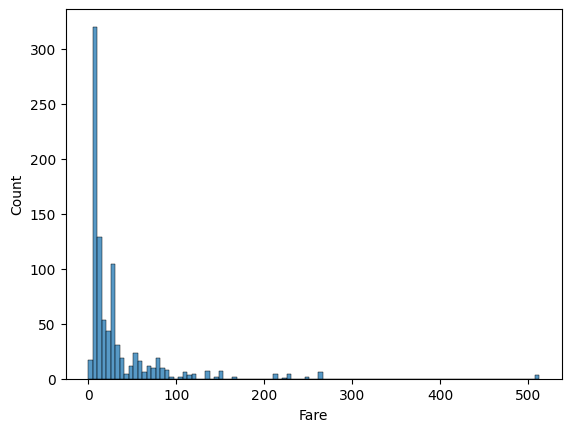

In [424]:
#visualize target feature
sns.histplot(df_train_new_features['Fare'],bins=100)

print(f'Skewness: {df_train_new_features.Fare.skew()}')
print(f'Kurtosis: {df_train_new_features.Fare.kurt()}')

In [425]:
df_train_new_features['logFare'] = np.log(df_train_new_features['Fare'] +1)
df_test_new_features['logFare'] = np.log(df_test_new_features['Fare'] +1)

### Drop columns not used in training

In [426]:
df_train_new_features = df_train_new_features.drop(['Fare','Name','Surname','Title' ],axis=1)
df_test_new_features = df_test_new_features.drop(['Fare','Name','Surname','Title' ],axis=1)

### Convert numerical features with a small number of unique values into categorical features

In [427]:
DataDescriber(df_train_new_features,'full').show_data()

,type,count,nunique,%unique,null,%null
Pclass,int64,891,3,0.336700,0,0.0
Sex,int64,891,2,0.224467,0,0.0
Age,float64,891,88,9.876543,0,0.0
SibSp,int64,891,7,0.785634,0,0.0
Parch,int64,891,7,0.785634,0,0.0
TicketGroupSize,int64,891,9,1.010101,0,0.0
Family_Size,int64,891,9,1.010101,0,0.0
Single,int64,891,2,0.224467,0,0.0
Small_Family,int64,891,2,0.224467,0,0.0
Large_Family,int64,891,2,0.224467,0,0.0


In [428]:
DataDescriber(df_test_new_features,'full').show_data()

,type,count,nunique,%unique,null,%null
Pclass,int64,418,3,0.717703,0,0.0
Sex,int64,418,2,0.478469,0,0.0
Age,float64,418,81,19.377990,0,0.0
SibSp,int64,418,7,1.674641,0,0.0
Parch,int64,418,8,1.913876,0,0.0
TicketGroupSize,int64,418,9,2.153110,0,0.0
Family_Size,int64,418,9,2.153110,0,0.0
Single,int64,418,2,0.478469,0,0.0
Small_Family,int64,418,2,0.478469,0,0.0
Large_Family,int64,418,2,0.478469,0,0.0


In [429]:
def dtypes_changer(df):
    for col in df.select_dtypes(include='number'):
        if df[col].nunique() <= 31:
            df[col] = df[col].astype('category')
    for col in df.select_dtypes(exclude='number'):      
        if df[col].dtype == 'object':
            df[col] = df[col].astype('category')
    
    return df

In [430]:
df_combined_for_dtypes = pd.concat([df_train_new_features,df_test_new_features], axis=0)

In [431]:
df_combined_dtypes_changed = dtypes_changer(df_combined_for_dtypes)

In [432]:
DataDescriber(df_combined_dtypes_changed,'full').show_data()

,type,count,nunique,%unique,null,%null
Age,float64,1309,99,7.563025,0,0.0
logFare,float64,1309,282,21.543163,0,0.0
Pclass,category,1309,3,0.229183,0,0.0
Sex,category,1309,2,0.152788,0,0.0
SibSp,category,1309,7,0.534759,0,0.0
Parch,category,1309,8,0.611154,0,0.0
Ticket,category,1309,37,2.826585,0,0.0
Cabin,category,1309,9,0.687548,0,0.0
Embarked,category,1309,3,0.229183,0,0.0
Title_mapped,category,1309,6,0.458365,0,0.0


### One-Hot encode categorical features

In [433]:
def final_get_dummies(df):
    df_categorical_columns = df.select_dtypes(include=['category'])
    cat_columns = list(df_categorical_columns)
    for col in df_categorical_columns:
        get_dummy = pd.get_dummies(df_categorical_columns[col], prefix=col, drop_first=True, dtype='bool')
        df_categorical_columns = pd.concat([df_categorical_columns, get_dummy], axis=1)
    df_dummies_columns = df_categorical_columns.drop(cat_columns, axis=1)
    df_final = pd.concat([df,df_dummies_columns], axis=1)
    return df_final.drop(cat_columns, axis=1)

In [434]:
data_for_dummies_prep = final_get_dummies(df_combined_dtypes_changed)

In [435]:
data_for_dummies_prep

,Age,logFare,Pclass_2,Pclass_3,Sex_1,SibSp_1,SibSp_2,SibSp_3,SibSp_4,SibSp_5,...,Family_Size_3,Family_Size_4,Family_Size_5,Family_Size_6,Family_Size_7,Family_Size_8,Family_Size_11,Single_1,Small_Family_1,Large_Family_1
0,22.0,2.110213,False,True,True,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,38.0,4.280593,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,26.0,2.188856,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,35.0,3.990834,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,35.0,2.202765,False,True,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,26.0,2.202765,False,True,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1305,39.0,4.699571,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1306,38.5,2.110213,False,True,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1307,26.0,2.202765,False,True,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [436]:
df_train_final = data_for_dummies_prep.iloc[:891]
df_test_final = data_for_dummies_prep.iloc[891:]

In [437]:
df_train_final = df_train_final.join(df_train['Survived'])

In [438]:
df_train_final

,Age,logFare,Pclass_2,Pclass_3,Sex_1,SibSp_1,SibSp_2,SibSp_3,SibSp_4,SibSp_5,...,Family_Size_4,Family_Size_5,Family_Size_6,Family_Size_7,Family_Size_8,Family_Size_11,Single_1,Small_Family_1,Large_Family_1,Survived
0,22.0,2.110213,False,True,True,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,0
1,38.0,4.280593,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,1
2,26.0,2.188856,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,1
3,35.0,3.990834,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,1
4,35.0,2.202765,False,True,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,27.0,2.639057,True,False,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,0
887,19.0,3.433987,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,1
888,18.0,3.196630,False,True,False,True,False,False,False,False,...,True,False,False,False,False,False,False,True,False,0
889,26.0,3.433987,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,1


# Model development

In [439]:
knn_class = KNeighborsClassifier()
tree_class = DecisionTreeClassifier()
forest_class = RandomForestClassifier()
svc_class = SVC()
ada_class = AdaBoostClassifier()
sgd_class = SGDClassifier()
ridge_class = RidgeClassifier()
log_class = LogisticRegression()
linSVC_class = LinearSVC()
gbc_class = GradientBoostingClassifier()
xgb_class = XGBClassifier(enable_categorical=True)
lgbm_class = LGBMClassifier(verbosity=-1)
cat_class = CatBoostClassifier(verbose=0)
models_list = {'CatBoost_Classifier':cat_class,
               'KNeighbors_Regression':knn_class,
               'Decision_Tree':tree_class, 
               'Random_Forest':forest_class,
               'AdaBoost_Classifier': ada_class,
               'SVC_Classifier':svc_class,
               'SGD_Classifier':sgd_class, 
               'Ridge_Classification':ridge_class,
               'Logistic_Regression':log_class, 
               'LinearSVC':linSVC_class,
               'GradientBoosting_Classification':gbc_class, 
               'XGBoost_Classification':xgb_class, 
               'LightGBM_Classification':lgbm_class}

In [440]:
df_results = pd.DataFrame(columns=['model','cv_method','basic_accuracy','accuracy_mean','accuracy_std','parameters'])

eval_methods = ['cross_val_score',
                'kfold',
                'repeatedkfold',
                'stratifiedkfold',
                'shufflesplit']

dataframes_dict = {'df_train_final': df_train_final}   

In [441]:
#pisane pod catboost
def basic_models(df_results, datasetname, models, cv_method, features_train, target_train, cat_cols):
    from sklearn.model_selection import cross_val_score, KFold, RepeatedKFold, StratifiedKFold, ShuffleSplit
    from sklearn.metrics import roc_auc_score
    import numpy as np
    import pandas as pd
    from catboost import CatBoostClassifier

    scoring = 'accuracy'
    cv = 10
    df_final = df_results.copy()
    for key, model in models.items():

        if cv_method == 'cross_val_score':
            train_X, test_X, train_y, test_y = train_test_split(features_train, target_train, test_size=0.2, random_state=1)
            if isinstance(model, CatBoostClassifier):
                tm = model.fit(train_X, train_y, cat_features=cat_cols, verbose=0)
                kf = KFold(n_splits=10, shuffle=True, random_state=1)
                scores = []
                for tr_idx, te_idx in kf.split(train_X):
                    X_tr, X_te = train_X.iloc[tr_idx], train_X.iloc[te_idx]
                    y_tr, y_te = train_y.iloc[tr_idx], train_y.iloc[te_idx]
                    tmp_model = CatBoostClassifier(**model.get_params())
                    tmp_model.fit(X_tr, y_tr, cat_features=cat_cols, verbose=0)
                    y_pred = tmp_model.predict(X_te)
                    scores.append(roc_auc_score(y_te, y_pred))
                score = np.array(scores)
            else:
                tm = model.fit(train_X, train_y)
                score = cross_val_score(model, train_X, train_y, scoring=scoring, cv=cv)
            tm_predict = tm.predict(test_X)
            prediction = roc_auc_score(test_y, tm_predict)
            df_created = pd.DataFrame({
                'datasetname': datasetname,
                'model': key,
                'cv_method': cv_method,
                'basic_accuracy': [prediction],
                'accuracy_mean': score.mean(),
                'accuracy_std': score.std(),
                'parameters': 'None'
            })
            df_full_results = pd.concat([df_results, df_created], axis=0, ignore_index=True)

        if cv_method == 'kfold':
            predictions = []
            accu = []
            kf = KFold(n_splits=10, shuffle=True, random_state=12)
            for train_index, test_index in kf.split(features_train):
                train_X, test_X = features_train.iloc[train_index], features_train.iloc[test_index]
                train_y, test_y = target_train.iloc[train_index], target_train.iloc[test_index]
                if isinstance(model, CatBoostClassifier):
                    tm = model.fit(train_X, train_y, cat_features=cat_cols, verbose=0)
                else:
                    tm = model.fit(train_X, train_y)
                tm_predict = tm.predict(test_X)
                prediction = roc_auc_score(test_y, tm_predict)
                accu.append(prediction)
                predictions.append(prediction)
                df_created = pd.DataFrame({
                    'datasetname': datasetname,
                    'model': key,
                    'cv_method': cv_method,
                    'basic_accuracy': [np.max(predictions)],
                    'accuracy_mean': np.mean(accu),
                    'accuracy_std': np.std(accu),
                    'parameters': 'None'
                })
                df_full_results = pd.concat([df_results, df_created], axis=0, ignore_index=True)

        if cv_method == 'repeatedkfold':
            predictions = []
            accu = []
            rkf = RepeatedKFold(n_splits=10, random_state=12)
            for train_index, test_index in rkf.split(features_train):
                train_X, test_X = features_train.iloc[train_index], features_train.iloc[test_index]
                train_y, test_y = target_train.iloc[train_index], target_train.iloc[test_index]
                if isinstance(model, CatBoostClassifier):
                    tm = model.fit(train_X, train_y, cat_features=cat_cols, verbose=0)
                else:
                    tm = model.fit(train_X, train_y)
                tm_predict = tm.predict(test_X)
                prediction = roc_auc_score(test_y, tm_predict)
                accu.append(prediction)
                predictions.append(prediction)
                df_created = pd.DataFrame({
                    'datasetname': datasetname,
                    'model': key,
                    'cv_method': cv_method,
                    'basic_accuracy': [np.max(predictions)],
                    'accuracy_mean': np.mean(accu),
                    'accuracy_std': np.std(accu),
                    'parameters': 'None'
                })
                df_full_results = pd.concat([df_results, df_created], axis=0, ignore_index=True)

        if cv_method == 'stratifiedkfold':
            predictions = []
            accu = []
            skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=12)
            for train_index, test_index in skf.split(features_train, target_train):
                train_X, test_X = features_train.iloc[train_index], features_train.iloc[test_index]
                train_y, test_y = target_train.iloc[train_index], target_train.iloc[test_index]
                if isinstance(model, CatBoostClassifier):
                    tm = model.fit(train_X, train_y, cat_features=cat_cols, verbose=0)
                else:
                    tm = model.fit(train_X, train_y)
                tm_predict = tm.predict(test_X)
                prediction = roc_auc_score(test_y, tm_predict)
                accu.append(prediction)
                predictions.append(prediction)
                df_created = pd.DataFrame({
                    'datasetname': datasetname,
                    'model': key,
                    'cv_method': cv_method,
                    'basic_accuracy': [np.max(predictions)],
                    'accuracy_mean': np.mean(accu),
                    'accuracy_std': np.std(accu),
                    'parameters': 'None'
                })
                df_full_results = pd.concat([df_results, df_created], axis=0, ignore_index=True)

        if cv_method == 'shufflesplit':
            predictions = []
            accu = []
            shs = ShuffleSplit(n_splits=10, test_size=0.2, random_state=12)
            for train_index, test_index in shs.split(features_train):
                train_X, test_X = features_train.iloc[train_index], features_train.iloc[test_index]
                train_y, test_y = target_train.iloc[train_index], target_train.iloc[test_index]
                if isinstance(model, CatBoostClassifier):
                    tm = model.fit(train_X, train_y, cat_features=cat_cols, verbose=0)
                else:
                    tm = model.fit(train_X, train_y)
                tm_predict = tm.predict(test_X)
                prediction = roc_auc_score(test_y, tm_predict)
                accu.append(prediction)
                predictions.append(prediction)
                df_created = pd.DataFrame({
                    'datasetname': datasetname,
                    'model': key,
                    'cv_method': cv_method,
                    'basic_accuracy': [np.max(predictions)],
                    'accuracy_mean': np.mean(accu),
                    'accuracy_std': np.std(accu),
                    'parameters': 'None'
                })
                df_full_results = pd.concat([df_results, df_created], axis=0, ignore_index=True)
        print(f'done model: {key}')
        df_row = pd.DataFrame({
            'datasetname': [df_full_results.loc[0]['datasetname']],
            'model': [df_full_results.loc[0]['model']],
            'cv_method': [df_full_results.loc[0]['cv_method']],
            'basic_accuracy': [df_full_results['basic_accuracy'].mean()],
            'accuracy_mean': [df_full_results.loc[0]['accuracy_mean']],
            'accuracy_std': [df_full_results.loc[0]['accuracy_std']],
            'parameters': 'None'
        })
        df_final = pd.concat([df_final, df_row], axis=0, ignore_index=True)
    return df_final

In [442]:
def train_models(df_results, dataframes_dict, eval_methods, models_list, cat_cols):

    final_result = []

    for key,value in dataframes_dict.items():
        features_train = value.drop('Survived', axis=1)
        target_train = value['Survived']
        print(f'training data: {key}')
        for method in eval_methods:
            print(f'training method: {method}')
            result = basic_models(df_results,key, models_list, method, features_train, target_train, cat_cols)
            final_result.append(result)
            print('done method')
        print('done data')

    final_data_of_trained_models = pd.concat(final_result, axis=0)
    return final_data_of_trained_models

In [443]:
cat_cols = df_train_final.select_dtypes(include='category').columns.tolist()
print(cat_cols)

[]


In [444]:
#df_models_trained = train_models(df_results,dataframes_dict,eval_methods,models_list, cat_cols)

In [445]:
#df_models_trained.to_csv('./v2_trained_basic_models.csv')

In [446]:
df_models_trained= pd.read_csv('../predictions/v2_trained_basic_models.csv', index_col=0)

In [447]:
df_models_trained.sort_values(by='roc_auc_mean', ascending=False).head(30)

,model,cv_method,basic_roc_auc,roc_auc_mean,roc_auc_std,parameters,datasetname
7,Ridge_Classification,cross_val_score,0.783277,0.890747,0.019905,NaN,df_train_final
8,Logistic_Regression,cross_val_score,0.796976,0.884842,0.026462,NaN,df_train_final
9,LinearSVC,cross_val_score,0.773843,0.883388,0.032741,NaN,df_train_final
10,GradientBoosting_Classification,cross_val_score,0.770031,0.883089,0.015266,NaN,df_train_final
3,Random_Forest,cross_val_score,0.769579,0.876399,0.028652,NaN,df_train_final
4,AdaBoost_Classifier,cross_val_score,0.792711,0.871025,0.023634,NaN,df_train_final
12,LightGBM_Classification,cross_val_score,0.751163,0.870832,0.015411,NaN,df_train_final
6,SGD_Classifier,cross_val_score,0.638666,0.865517,0.042179,NaN,df_train_final
11,XGBoost_Classification,cross_val_score,0.753295,0.859993,0.021411,NaN,df_train_final
5,SVC_Classifier,cross_val_score,0.535474,0.828227,0.047132,NaN,df_train_final


# Tuning models with GridSearch

In [448]:
final_models_list = {'Ridge_Classification':ridge_class,
                     'XGBoost_Classification':xgb_class,
                     'LightGBM_Classification':lgbm_class, 
                     'GradientBoosting_Classification':gbc_class,
                     'Random_Forest':forest_class,
                     'Logistic_Regression':log_class}

In [449]:
final_models_with_params_search = {
    
    'Ridge_Classification':{'alpha':[1,2,3,4,5,6,7,10],
                            'fit_intercept':[True, False],
                            'solver':['auto', 'svd', 'cholesky', 
                                      'lsqr', 'sparse_cg', 'sag', 
                                      'saga', 'lbfgs']
                           },
    
    'XGBoost_Classification':{'verbosity':[0],
                              'booster':['gbtree','gblinear','dart'],
                             },
    
    'LightGBM_Classification':{'boosting_type':['gbdt','dart'],
                               'n_estimators':[100,200,300],
                               'n_jobs':[-1],
                               'class_weight':[None,'balanced'],
                               'learning_rate':[0.1,0.05,0.2],
                               },
    
    'GradientBoosting_Classification':{'loss':['log_loss','exponential'],
                                       'learning_rate':[0.05,0.1,0.2],
                                       'n_estimators':[100,200,400],
                                       'subsample':[0.1,0.5,1.0],
                                       'criterion':['friedman_mse','squared_error'],
                                       'max_features':['sqrt','log2',None]},
    
    'Random_Forest':{'n_estimators':[10,50,100,200,400],
                     'criterion':['gini','entropy','log_loss'],
                     'max_features':['sqrt','log2', None],
                     'n_jobs':[-1],
                     'class_weight':['balanced','balanced_subsample', None]},
    
    'Logistic_Regression':{'penalty':['l1','l2'],
                           'C':[0.1,0.5,1.0,1.5],
                           'class_weight':['balanced', None],
                           'solver':['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'],
                           'n_jobs':[-1]}
    
    
}

In [450]:
my_dict = dict()
for name,value in dataframes_dict.items():
    features_train = value.drop('Survived', axis=1)
    target_train = value['Survived']
    print(f'training data: {name}')
    for key,model in final_models_list.items():
        gridsearch = GridSearchCV(model,final_models_with_params_search[key], cv=5,scoring='accuracy',verbose=0)
        best_model = gridsearch.fit(features_train, target_train)
        print(f'{key}:{best_model.best_estimator_}')
        my_dict[key]=(name, best_model.best_estimator_)
my_dict

training data: df_train_final
Ridge_Classification:RidgeClassifier(alpha=3, fit_intercept=False, solver='saga')
XGBoost_Classification:XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)
LightGBM_Classification:LGBMClassifier(boosting_type='dart', learning_rate=0.05, n_estimators=200,
     

/home/airdj/Desktop/Airdj_codes/data_science_env/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/airdj/Desktop/Airdj_codes/data_science_env/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https:/

Logistic_Regression:LogisticRegression(n_jobs=-1)


/home/airdj/Desktop/Airdj_codes/data_science_env/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Ridge_Classification': ('df_train_final',
  RidgeClassifier(alpha=3, fit_intercept=False, solver='saga')),
 'XGBoost_Classification': ('df_train_final',
  XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=True, eval_metric=None, feature_types=None,
                gamma=None, grow_policy=None, importance_type=None,
                interaction_constraints=None, learning_rate=None, max_bin=None,
                max_cat_threshold=None, max_cat_to_onehot=None,
                max_delta_step=None, max_depth=None, max_leaves=None,
                min_child_weight=None, missing=nan, monotone_constraints=None,
                multi_strategy=None, n_estimators=None, n_jobs=None,
                num_parallel_tree=None, random_state=None, ...)),
 'LightGBM_Classification': ('df_train_final',
  LGBMClassif

In [451]:
# {'Ridge_Classification': ('df_train_final',
#   RidgeClassifier(alpha=3, fit_intercept=False, solver='saga')),
#  'XGBoost_Classification': ('df_train_final',
#   XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
#                 colsample_bylevel=None, colsample_bynode=None,
#                 colsample_bytree=None, device=None, early_stopping_rounds=None,
#                 enable_categorical=True, eval_metric=None, feature_types=None,
#                 gamma=None, grow_policy=None, importance_type=None,
#                 interaction_constraints=None, learning_rate=None, max_bin=None,
#                 max_cat_threshold=None, max_cat_to_onehot=None,
#                 max_delta_step=None, max_depth=None, max_leaves=None,
#                 min_child_weight=None, missing=nan, monotone_constraints=None,
#                 multi_strategy=None, n_estimators=None, n_jobs=None,
#                 num_parallel_tree=None, random_state=None, ...)),
#  'LightGBM_Classification': ('df_train_final',
#   LGBMClassifier(boosting='dart', learning_rate=0.05, n_estimators=200, n_jobs=-1,
#                  verbosity=-1)),
#  'GradientBoosting_Classification': ('df_train_final',
#   GradientBoostingClassifier(learning_rate=0.2, n_estimators=200)),
#  'Random_Forest': ('df_train_final',
#   RandomForestClassifier(class_weight='balanced_subsample', criterion='log_loss',
#                          max_features=None, n_jobs=-1)),
#  'Logistic_Regression': ('df_train_final', LogisticRegression(n_jobs=-1))}

In [452]:
my_dict.keys()

dict_keys(['Ridge_Classification', 'XGBoost_Classification', 'LightGBM_Classification', 'GradientBoosting_Classification', 'Random_Forest', 'Logistic_Regression'])

# Train models with hyperparameters

In [453]:
#prepare final models with params for training data
ridge_class_params = my_dict['Ridge_Classification'][1]

xgb_class_params = my_dict['XGBoost_Classification'][1]

lgbm_class_params = my_dict['LightGBM_Classification'][1]

gbc_class_params = my_dict['GradientBoosting_Classification'][1]

forest_class_params = my_dict['Random_Forest'][1]

log_class_params = LogisticRegression(n_jobs=-1, max_iter=1000)

vot_class = VotingClassifier([('ridge',ridge_class_params),
                              ('logistic',log_class_params),
                              ('forest',forest_class_params),
                              ('lgbm',lgbm_class_params)])



final_models_list_with_params = {'Ridge_Classification':ridge_class_params,
                     'XGBoost_Classification':xgb_class_params,
                     'LightGBM_Classification':lgbm_class_params, 
                     'GradientBoosting_Classification':gbc_class_params,
                     'Random_Forest':forest_class_params,
                     'Logistic_Regression':log_class_params,
                     'Voting_Classifier': vot_class}

In [454]:
df_models_trained_with_params = train_models(df_results,dataframes_dict,eval_methods,final_models_list_with_params, cat_cols)

training data: df_train_final
training method: cross_val_score
done model: Ridge_Classification
done model: XGBoost_Classification
done model: LightGBM_Classification
done model: GradientBoosting_Classification
done model: Random_Forest
done model: Logistic_Regression
done model: Voting_Classifier
done method
training method: kfold
done model: Ridge_Classification
done model: XGBoost_Classification
done model: LightGBM_Classification
done model: GradientBoosting_Classification
done model: Random_Forest
done model: Logistic_Regression
done model: Voting_Classifier
done method
training method: repeatedkfold
done model: Ridge_Classification
done model: XGBoost_Classification
done model: LightGBM_Classification
done model: GradientBoosting_Classification
done model: Random_Forest
done model: Logistic_Regression
done model: Voting_Classifier
done method
training method: stratifiedkfold
done model: Ridge_Classification
done model: XGBoost_Classification
done model: LightGBM_Classification
do

In [455]:
df_models_trained_with_params.sort_values(by='accuracy_mean', ascending=False).head(20)

,model,cv_method,basic_accuracy,accuracy_mean,accuracy_std,parameters,datasetname
2,LightGBM_Classification,cross_val_score,0.749483,0.830106,0.033298,None,df_train_final
6,Voting_Classifier,cross_val_score,0.800465,0.828736,0.025072,None,df_train_final
4,Random_Forest,cross_val_score,0.776880,0.824531,0.036317,None,df_train_final
3,GradientBoosting_Classification,cross_val_score,0.769579,0.824491,0.041637,None,df_train_final
3,GradientBoosting_Classification,stratifiedkfold,0.855080,0.823590,0.021736,None,df_train_final
5,Logistic_Regression,cross_val_score,0.803825,0.823220,0.044920,None,df_train_final
4,Random_Forest,kfold,0.905445,0.821863,0.045119,None,df_train_final
0,Ridge_Classification,cross_val_score,0.820109,0.817606,0.047772,None,df_train_final
2,LightGBM_Classification,repeatedkfold,0.909622,0.813191,0.047084,None,df_train_final
3,GradientBoosting_Classification,repeatedkfold,0.913642,0.812093,0.039635,None,df_train_final


In [458]:
df_models_trained_with_params.to_csv('./v2_trained_models_with_params_df.csv')

In [459]:
# df_models_trained_with_params = pd.read_csv('v2_trained_models_with_params_df.csv', index_col=0)
# df_models_trained_with_params.sort_values(by='accuracy_mean', ascending=False).head(20)

In [460]:
final_train_features = df_train_final.drop('Survived', axis=1)
final_train_target = df_train_final['Survived']

In [473]:
final_model = vot_class

In [466]:
final_model.fit(final_train_features,final_train_target)

LGBMClassifier(boosting_type='dart', learning_rate=0.05, n_estimators=200,
               n_jobs=-1, verbosity=-1)

In [467]:
predictions = final_model.predict(df_test_final)

In [468]:
# output = pd.DataFrame({'PassengerId': df_test.PassengerId,
#                        'Survived': predictions.astype('int')})
# output.to_csv('v2_final_predictions2.csv', index=False)

# Feature Selection

In [469]:
clf = RandomForestClassifier(n_estimators=50, max_features='sqrt')
clf.fit(final_train_features,final_train_target)

RandomForestClassifier(n_estimators=50)

<Axes: ylabel='feature'>

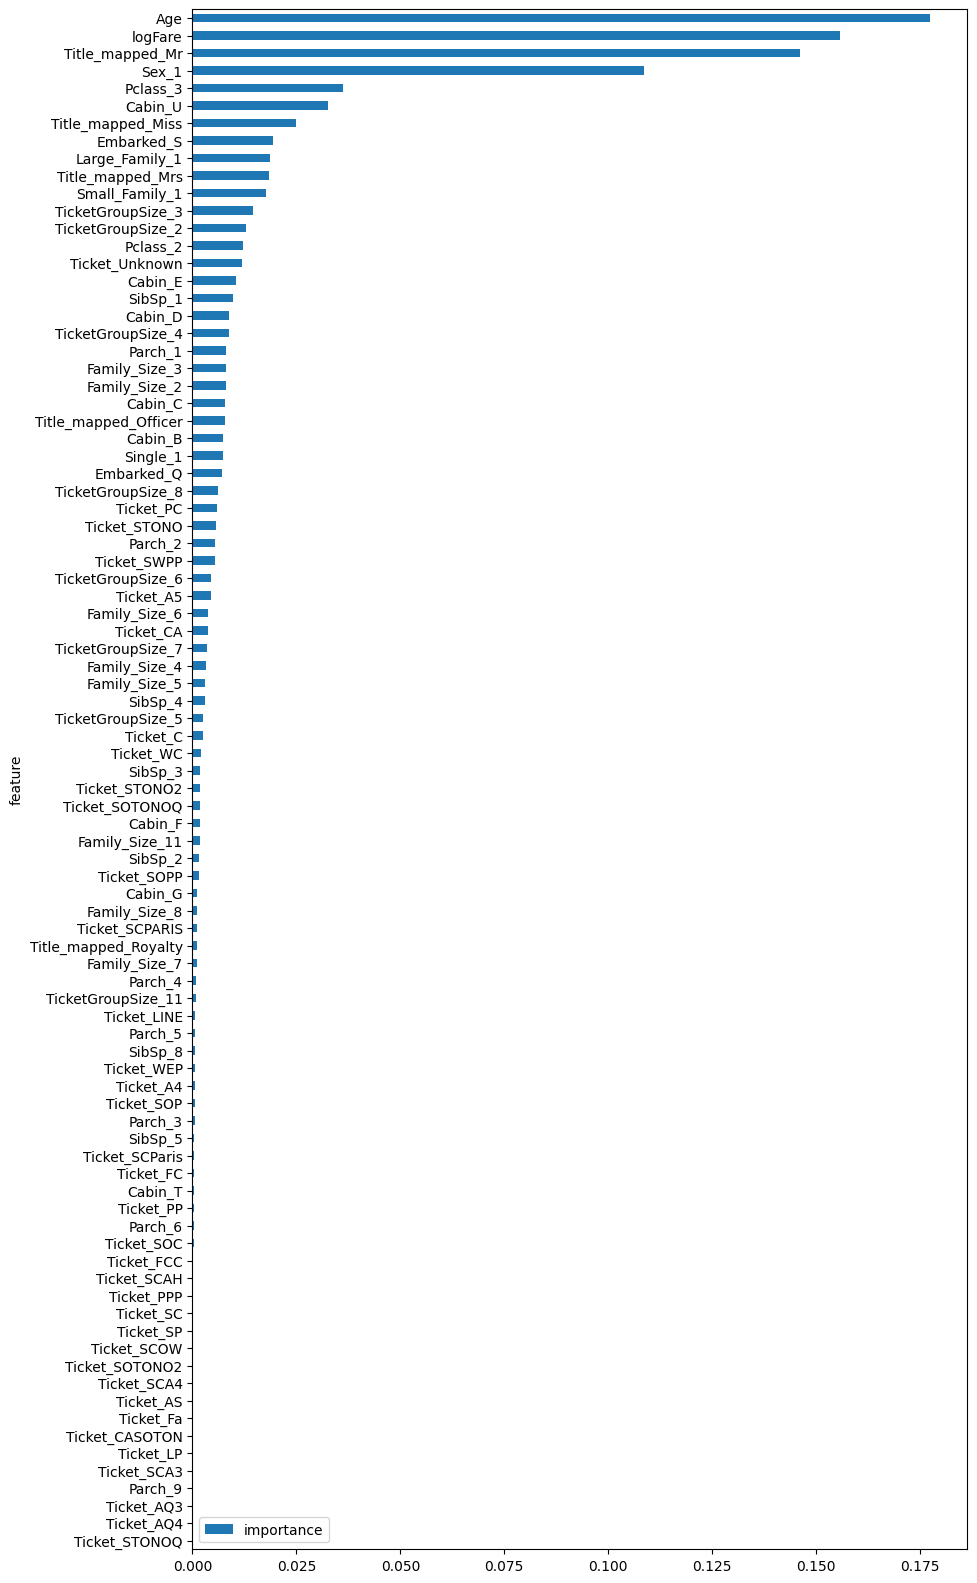

In [470]:
features = pd.DataFrame()
features['feature'] = final_train_features.columns
features['importance'] = clf.feature_importances_
features.sort_values(by=['importance'], ascending=True, inplace=True)
features.set_index('feature', inplace=True)

features.plot(kind='barh', figsize=(10, 20))

In [471]:
reduced_model = SelectFromModel(clf, prefit=True)
train_reduced = reduced_model.transform(final_train_features)
test_reduced = reduced_model.transform(df_test_final)

print(train_reduced.shape, test_reduced.shape)

(891, 15) (418, 15)


In [474]:
final_model.fit(train_reduced,final_train_target)

VotingClassifier(estimators=[('ridge',
                              RidgeClassifier(alpha=3, fit_intercept=False,
                                              solver='saga')),
                             ('logistic',
                              LogisticRegression(max_iter=1000, n_jobs=-1)),
                             ('forest',
                              RandomForestClassifier(class_weight='balanced',
                                                     criterion='log_loss',
                                                     max_features=None,
                                                     n_estimators=50,
                                                     n_jobs=-1)),
                             ('lgbm',
                              LGBMClassifier(boosting_type='dart',
                                             learning_rate=0.05,
                                             n_estimators=200, n_jobs=-1,
                                             verbosity=-1))])

In [475]:
predictions2 = final_model.predict(test_reduced)

In [476]:
output2 = pd.DataFrame({'PassengerId': df_test.PassengerId,
                       'Survived': predictions2.astype('int')})
output2.to_csv('v2_reduced_predictions.csv', index=False)